<a href="https://colab.research.google.com/github/tofighi/tutorials/blob/master/AI/Assignments/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From-Scratch Logistic Regression (Hours Studied)

**Objective:** Implement standard binary Logistic Regression from scratch using Gradient Descent for a simple 1D dataset (hours of studying vs. exam result). You are **not allowed to use any machine learning libraries** like Scikit-Learn for the model training and optimization part; however, `numpy` is permitted for numerical operations.

**Model:**
Your task is to fit the following logistic hypothesis function to the provided dataset:
$$\boxed{\hat{y} = h_{\theta}(x) = \sigma(\theta_0 + \theta_1 x) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x)}}}$$


### Provided Dataset
We will use a simple dataset representing hours studied and whether a student passed (1) or failed (0) the exam.


Hours Studied: [ 2  5  9 12 15 18 22 25 28 30 33 35 40]
Exam Result  (0=Fail, 1=Pass): [0 0 0 0 0 0 1 0 1 1 1 1 1]
Number of samples (m): 13


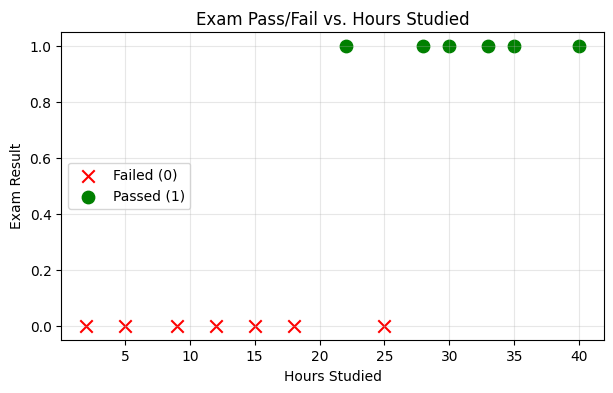

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hours studied and exam pass/fail results
hours = np.array([2, 5, 9, 12, 15, 18, 22, 25, 28, 30, 33, 35, 40])
result = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1])

m = len(result) # Number of training samples

print("Hours Studied:", hours)
print("Exam Result  (0=Fail, 1=Pass):", result)
print("Number of samples (m):", m)

# Plot the dataset
plt.figure(figsize=(7, 4))
plt.scatter(hours[result == 0], result[result == 0], color='red', marker='x', s=80, label='Failed (0)')
plt.scatter(hours[result == 1], result[result == 1], color='green', marker='o', s=80, label='Passed (1)')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Result')
plt.title('Exam Pass/Fail vs. Hours Studied')
plt.legend(loc='center left')
plt.grid(True, alpha=0.3)
plt.show()


### Tasks

**Implement Logistic Regression**

1.  **Initialize Parameters:** Start with parameter variables `theta_0` (intercept) and `theta_1` (slope) set to $0.0$.
2.  **Define Hyperparameters:** Choose a `learning_rate` ($\alpha$) and number of `iterations`. Experiment with different values.
3.  **Implement Gradient Descent:**
    *   For a fixed number of iterations, perform the following steps:
        *   Calculate prediction probability for each sample $i$ using the sigmoid function:

            $$p^{(i)} = \sigma(\theta_0 + \theta_1 x^{(i)}) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x^{(i)})}}$$

        *   Calculate the Mean Cross-Entropy Cost $J(\theta)$ (the loss over all $m$ samples):

            $$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log\left(p^{(i)}\right) + (1 - y^{(i)}) \log\left(1 - p^{(i)}\right) \right]$$

        *   Calculate the partial derivatives (gradients) with respect to each parameter:
            *   Intercept derivative: $\frac{\partial J}{\partial \theta_0} = \frac{1}{m}\sum_{i=1}^{m}\left(p^{(i)} - y^{(i)}\right)$
            *   Slope derivative: $\frac{\partial J}{\partial \theta_1} = \frac{1}{m}\sum_{i=1}^{m}\left(p^{(i)} - y^{(i)}\right)x^{(i)}$
        *   Update both parameters simultaneously using the Gradient Descent update rule:
            *   $\theta_0 := \theta_0 - \alpha \frac{\partial J}{\partial \theta_0}$
            *   $\theta_1 := \theta_1 - \alpha \frac{\partial J}{\partial \theta_1}$
4.  **Track Progress:** Store the cost value $J(\theta)$ at each iteration.
5.  **Report Results:** Print the final optimized parameters ($\theta_0, \theta_1$) and the final cost.
6.  **Visualize:**
    *   Plot the cost function over iterations to show convergence.
    *   Plot the final fitted sigmoid probability curve on top of the dataset scatter plot. Also plot a vertical line at the **decision boundary** (where the probability is $0.5$):
    
        $$x = -\frac{\theta_0}{\theta_1}$$

**Discussion (in a markdown cell):**
*   What is the computed decision boundary hours? Does it logically separate passing students from failing students in the plot?
*   How does changing the `learning_rate` ($\alpha$) affect the cost convergence behavior?
